In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
import pandas as pd
import numpy as np

# Method 1: Using pandas (recommended - easiest to work with)
def load_with_pandas(filepath):
    """
    Load the .dat file using pandas
    Returns a DataFrame with column names and data
    """
    df = pd.read_csv(filepath, sep=r'\s+')
    return df

# Method 2: Using numpy
def load_with_numpy(filepath):
    """
    Load the .dat file using numpy
    Returns a structured array or regular array
    Note: This file has variable columns per row, so we'll use pandas internally
    """
    # For this file with varying columns, pandas handles it better
    # But we can convert to numpy array
    import pandas as pd
    df = pd.read_csv(filepath, sep=r'\s+')
    
    # Convert to numpy array
    data = df.values
    headers = df.columns.tolist()
    
    return data, headers

In [3]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

### Parameters

In [4]:
fname = '../../../../../../Data/Fig5_Input_Data/animal_trajectories/moth/1Oct08E.3.dat'
df = load_with_pandas(fname)

flow_direction = np.pi
flow_condition = 'turbulent'
flow_speed = 1.
body_length = 0.07
locomotion = 'flying'
medium = 'air'
group = 'aerial'

interp_dt = 0.01

### Get time stamps and speed -- this is custom per data type

In [5]:
df

,time,x,y,z,groundspeedxy,groundspeedxz,groundspeedxyz,trackanglexy,trackanglexz,trackanglexyz,airspeedxy,airspeedxz,airspeedxyz,courseanglexy,courseanglexz,courseanglexyz,driftanglexy,driftanglexz,driftanglexyz
0,0.00,-0.905,0.257,-0.637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.03,-0.896,0.251,-0.603,0.32,1.04,1.05,-34.14,-75.43,75.64,1.27,1.61,1.62,-7.99,-38.54,38.97,-26.15,-36.89,36.68
2,0.07,-0.895,0.242,-0.572,0.30,0.96,1.00,-82.60,-87.72,87.82,1.08,1.41,1.44,-15.77,-42.65,43.93,-66.83,-45.07,43.89
3,0.10,-0.893,0.240,-0.549,0.07,0.67,0.67,-44.73,-85.62,85.63,1.05,1.25,1.25,-2.77,-32.47,32.55,-41.96,-53.15,53.08
4,0.13,-0.896,0.242,-0.517,0.11,0.96,0.96,154.65,-95.86,95.85,0.90,1.32,1.32,2.96,-46.74,46.77,151.69,-49.12,49.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,9.07,-0.126,0.212,-0.261,0.40,0.32,0.40,38.35,1.08,38.36,1.34,1.32,1.34,10.79,0.26,10.79,27.56,0.82,27.56
273,9.10,-0.115,0.226,-0.261,0.53,0.34,0.53,49.30,1.22,49.31,1.40,1.34,1.40,16.60,0.31,16.60,32.70,0.90,32.70
274,9.13,-0.110,0.242,-0.262,0.53,0.15,0.53,73.92,2.11,73.92,1.25,1.15,1.25,23.93,0.27,23.94,49.99,1.84,49.99
275,9.17,-0.109,0.255,-0.251,0.38,0.31,0.49,87.72,-87.15,88.22,1.08,1.06,1.13,20.62,-16.72,25.70,67.11,-70.43,62.52


In [6]:
scaling = 1

In [7]:
df_calibrated = df[['x', 'y']].copy()

df_calibrated['timestamps_sec'] = df.time

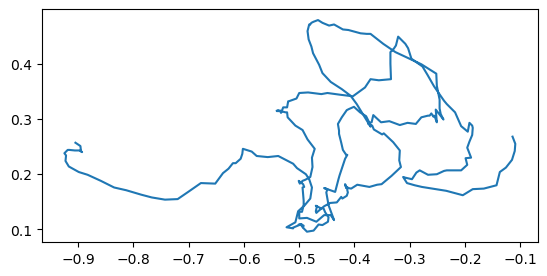

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.set_aspect('equal')

### Interpolate

In [9]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), interp_dt)

spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=5e-3, k=5)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=5e-3, k=5)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

### Parameters

In [10]:
df_calibrated_interp.shape

(920, 3)

In [11]:
tix_start = 100
tix_end = 910

1.0


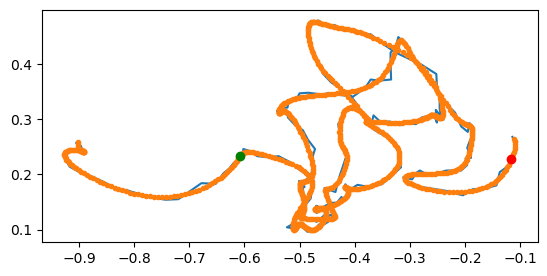

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [13]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [14]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

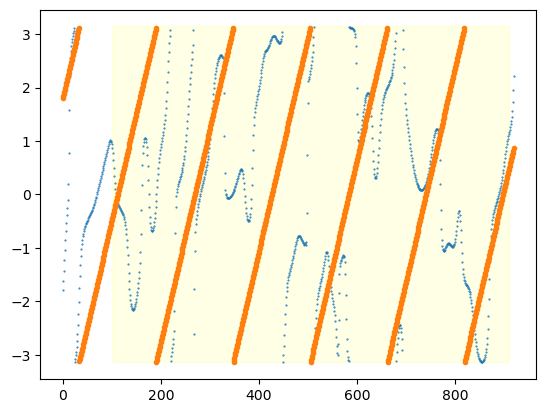

In [15]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = 0.04
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [16]:
min_ix_range = 200
max_ix_range = 300

In [17]:
trajec = df_calibrated_interp

In [18]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [19]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)

trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

In [20]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,)

Restricted license - for non-production use only - expires 2027-11-29


SolverError: Solver 'GUROBI' failed. Try another solver, or solve with verbose=True for more information.

In [21]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length

unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [22]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [23]:
sorted_fit

,min_ix,max_ix,abs_min_ix,abs_max_ix,min_ix_range,max_ix_range,slope,intercept,rotation,major_axis,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
3,285,517,100,910,200,300,0.057914,-3.375849,2.390734,0.992178,...,3,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
0,685,902,100,910,200,300,-0.026421,7.139897,-2.273541,0.788516,...,0,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
4,140,429,100,910,200,300,0.065586,0.554977,2.783459,0.862676,...,4,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
7,190,401,100,910,200,300,-0.002078,7.135269,2.524750,1.161494,...,7,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
9,247,452,100,910,200,300,0.066536,-6.173831,2.882279,0.941173,...,9,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
5,683,900,100,910,200,300,-0.026281,-5.435941,-2.364731,0.782433,...,5,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
8,176,459,100,910,200,300,0.062181,1.116956,2.703866,0.814991,...,8,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
6,308,527,100,910,200,300,0.038596,-7.139125,3.094307,0.864361,...,6,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
1,508,726,100,910,200,300,-0.073857,3.137979,-2.899556,0.705683,...,1,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
2,250,517,100,910,200,300,0.040578,4.513793,2.975382,0.767836,...,2,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial


In [24]:
ix_all, course, linear_fit_angle, affine_fit_angle, shift_ix_adj = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

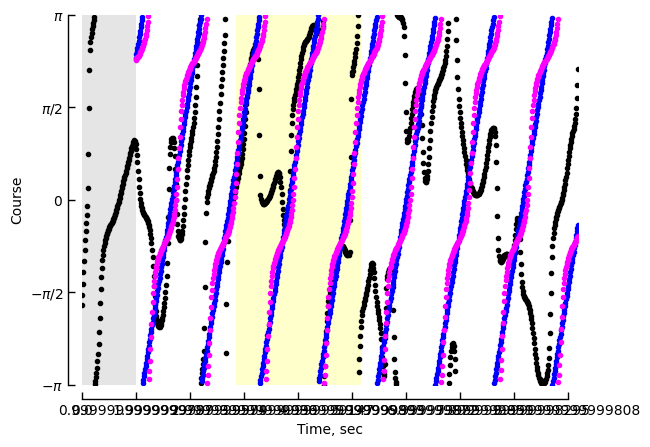

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [26]:
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')

In [27]:
unifying_algo_fit

,min_ix,max_ix,abs_min_ix,abs_max_ix,min_ix_range,max_ix_range,slope,intercept,rotation,major_axis,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
0,685,902,100,910,200,300,-0.026421,7.139897,-2.273541,0.788516,...,0,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
1,508,726,100,910,200,300,-0.073857,3.137979,-2.899556,0.705683,...,1,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
2,250,517,100,910,200,300,0.040578,4.513793,2.975382,0.767836,...,2,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
3,285,517,100,910,200,300,0.057914,-3.375849,2.390734,0.992178,...,3,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
4,140,429,100,910,200,300,0.065586,0.554977,2.783459,0.862676,...,4,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
5,683,900,100,910,200,300,-0.026281,-5.435941,-2.364731,0.782433,...,5,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
6,308,527,100,910,200,300,0.038596,-7.139125,3.094307,0.864361,...,6,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
7,190,401,100,910,200,300,-0.002078,7.135269,2.524750,1.161494,...,7,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
8,176,459,100,910,200,300,0.062181,1.116956,2.703866,0.814991,...,8,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
9,247,452,100,910,200,300,0.066536,-6.173831,2.882279,0.941173,...,9,1Oct08E,0.009,3.141593,turbulent,1.0,0.07,flying,air,aerial
